---
title: "Particle method for stochastic local volatility valibration"
subtitle: "A numerical implementation of Guyon & Henry-Labordère (2011)"
author:
  name: Cheryl KOUADIO
categories: [paper, m2mo, options]
date: "2026-06-21"
execute:
  echo: true
  output: false
  warning: false
---

Derivatives are financial instruments whose value depends on one or several underlying risk factors. Their contractual cash flows are determined by a payoff function, possibly path-dependent, which specifies how future payments depend on the evolution of the underlying asset. As market prices are unpredictable, models are needed to attempt to understand the explicable structure of price formation while accounting for its unexplainable part. This can, for example, help to hedge efficiently.

A foundational model in option pricing is the Black–Scholes model [@black1973pricing], introduced in 1973. It assumes that the underlying asset follows a geometric Brownian motion with constant volatility $\sigma$, deterministic interest rate $r$, and standard Brownian motion $W_t$. This framework yields closed-form formulae for European call and put options, making it possible to infer an implied volatility from observed option prices. Through this model, one can try to understand the effect of many factors on price formation. This is what is referred to as the Greeks.

One major limitation of the Black–Scholes model is its constant volatility assumption, meaning volatility has a constant impact on price formation. However, market option prices imply volatilities that vary across strikes and maturities, forming smiles and skews that are inconsistent with the use of a single constant volatility parameter. To address this shortcoming, several classes of models have been developed: local volatility models, where volatility depends on time and the underlying price; stochastic volatility models, where volatility follows its own random dynamics; and stochastic local volatility models, which combine both approaches. However, the central difficulty remains the calibration of these richer volatility models to the observed implied volatility surface.

In this article, we focus on the particle method proposed by Guyon and Henry-Labordère [@guyon2011smile] for the calibration of stochastic local volatility models. More precisely, the method aims at estimating the leverage function that allows the model to reproduce the market smile while preserving a chosen stochastic volatility dynamics. We first trace the evolution from Black–Scholes to stochastic local volatility models. We then present the particle method and its implementation on a numerical example.

## From Black–Scholes Constant Volatility to Stochastic Local Volatility: a brief theoretical background

### Black–Scholes model

The Black–Scholes model [@black1973pricing], introduced in 1973, is a foundational model in option pricing. Its main idea is to model the underlying asset price through a lognormal dynamics. Under the risk-neutral measure, the asset price follows the stochastic differential equation

$$
dS_t = rS_tdt + \sigma S_tdW_t,
$$

where $\sigma$ is a constant volatility, $r$ is a deterministic risk-free rate, and $W_t$ is a standard Brownian motion, that is normally distributed with law $\mathcal{N}(0,t)$.

That being said, one can obtain an explicit expression for the spot price $S_t = S_0 \exp\left(\left(r-\frac{\sigma^2}{2}\right)t + \sigma W_t\right)$.

Taking a close look at this formulae, we can identify a log normal structure of spot price that allows European option prices to be computed explicitly. For example, for a European call option with strike $K$ and maturity $T$, the risk-neutral price at time $t$ is

$$
\begin{align*}
\Pi_{\mathrm{Call}}(t) &= e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}} \left[ \max(S_T-K,0) \mid \mathcal{F}_t \right] \\
&= S_t\Phi(d_+) - Ke^{-r\tau}\Phi(d_-).
\end{align*}
$$

where $\tau = T-t$, $\Phi$ is the cumulative distribution function of the standard normal distribution, and $ d_\pm = \frac{ \ln(S_t/K)+\left(r \pm \frac{\sigma^2}{2}\right)\tau}{ \sigma\sqrt{\tau}}$.

The main limitation of this model is the assumption that volatility is constant. In practice, market option prices imply different volatilities for different strikes and maturities, producing the well-known implied volatility smile or skew. This observation motivates the introduction of richer volatility models.

### Local Volatility: Dupire model

To address the empirical fact that volatility is not constant across strikes and maturities, Bruno Dupire introduced the local volatility model in 1994 [@dupire1994pricing]. In this framework, the volatility is no longer constant, but is instead a deterministic function of time and the underlying asset price. The asset price dynamics are given by

$$
dS_t = rS_tdt + \sigma_{\mathrm{loc}}(t,S_t)S_tdW_t.
$$

<!-- This framework preserves market completeness in the idealized Black–Scholes sense, since the only source of randomness is the Brownian motion driving the underlying asset. As a result, contingent claims can in principle be replicated by dynamic trading in the underlying asset and the risk-free asset. -->

Allowing the volatility to depend on both $t$ and $S_t$ is particularly useful because it gives enough flexibility to match the full implied volatility surface observed in the market. However, market quotes are not directly expressed as functions of the future spot process $S_t$. Instead, European option prices are observed as a function of strike $K$ and maturity $T$. We can therefore view market call prices as a surface $\Pi_{\mathrm{Call}}(t) = C(K,T).$

By differentiating this surface with respect to strike and maturity, Dupire derived a formula linking the observed option price surface to the local volatility function. Assuming constant interest rate $r$, the local volatility is given by

$$
\sigma_{\mathrm{loc}}^2(K,T) = \frac{ \partial_T C(K,T) + r K\partial_K C(K,T)}{
    \frac{1}{2}K^2\partial_{KK}C(K,T)}.
$$

This formula shows that, under suitable regularity and no-arbitrage conditions, the local volatility surface can be recovered from European call prices. The local volatility model can therefore be calibrated exactly to the market implied volatility surface at the initial calibration date.
Its main drawback, however, is dynamic. Although the model perfectly reproduces today’s vanilla option prices, the future evolution of the smile generated by the model is generally not consistent with the forward smile dynamics observed in the market. This limitation motivates the introduction of stochastic volatility models and, ultimately, stochastic local volatility models.

### Stochastic volatility models

Stochastic volatility models were introduced to better reproduce the empirical dynamics of financial markets by allowing volatility itself to evolve randomly over time. Unlike the Black–Scholes model, where volatility is constant, these models introduce additional state variables that generate richer smile dynamics and more realistic volatility behavior. However, by adding a second source of randomness, they generally lead to market incompleteness. This mean, we could not perfectly hedge a derivative with the spot as underlying. Moreover, when specified with a finite number of parameters, they usually cannot fit an arbitrary implied volatility surface exactly.

In such models, the spot price typically follows a dynamics of the form : $dS_t = rS_tdt + \sigma_t S_tdW_t$, where $\sigma_t$ is now a stochastic process.
Several stochastic volatility models have been proposed in the literature. One of the most widely used is the Heston model, introduced by Steven Heston. Under the risk-neutral measure, its dynamics are given by

$$
dS_t = rS_tdt + \sqrt{v_t}S_tdW_t^S, \\
dv_t = \kappa(\theta-v_t)dt + \xi\sqrt{v_t}dW_t^v, \\
d\langle W^S, W^v\rangle_t = \rho dt,
$$

where $v_t$ denotes the instantaneous variance. The parameter $\kappa$ is the mean-reversion speed, $\theta$ is the long-term variance level, $\xi$ is the volatility of volatility, and $\rho$ is the instantaneous correlation between the Brownian motion driving the asset price and the Brownian motion driving the variance.
Through these parameters, the model captures the stylized features of volatility dynamics.

<!-- The parameters $\kappa$ and $\theta$ encode the assumption that variance tends to revert toward a long-run level $\theta$. The larger $\kappa$ is, the faster this mean reversion occurs. The parameter $\xi$ controls the magnitude of random fluctuations in variance. Finally, the correlation parameter $\rho$ plays a crucial role in shaping the implied volatility skew. A negative value of $\rho$ captures the leverage effect: downward shocks in the spot price tend to be associated with upward shocks in variance, which typically produces a negative skew in implied volatilities. -->

### Stochastic local volatility models

Knowing the respective advantages and drawbacks of local and stochastic volatility models, the stochastic local volatility framework was developed to combine the exact calibration capability of local volatility models with the richer smile dynamics generated by stochastic volatility models. A stochastic local volatility model can be written as follows :

$$
dS_t = rS_tdt + a_t l(t,S_t)S_tdW_t^S,
$$

where $a_t$ is a stochastic volatility factor and $l(t,S)$ is a deterministic function called the leverage function.

The goal of introducing the stochastic factor $a_t$ is to capture featurs of stochastic volatility models. That is to reproduce more realistic forward smile dynamics and volatility clustering effects observed in the market, while retaining enough flexibility to calibrate the model to vanilla option prices. The leverage function $l(t,S)$ is then chosen so that the SLV model matches the market prices of European vanilla options, or equivalently, the market implied volatility surface.

More precisely, the leverage function is calibrated so that the one-dimensional marginal distributions of the SLV model coincide with those implied by the corresponding local volatility model. This condition leads to the relation

$$
l^2(t,S) = \frac{\sigma_{\mathrm{loc}}^2(t,S)}{\mathbb{E}\left[a_t^2 \mid S_t=S\right]},
$$

where $\sigma_{\mathrm{loc}}(t,S)$ denotes the local volatility surface obtained from Dupire’s formula.

Hence, the local volatility component ensures exact calibration to European vanilla option prices, while the stochastic volatility factor provides more realistic dynamics for exotic derivatives and forward smiles. The main numerical difficulty lies in the conditional expectation appearing in the denominator, since it depends on the joint distribution of the spot and the stochastic volatility factor. This is precisely where the particle method of Guyon and Henry-Labordère becomes useful.

The calibration problem is therefore transformed into the numerical estimation of a conditional expectation. Since this expectation depends on the law of the process being calibrated, the resulting dynamics are nonlinear in the McKean sense. Guyon and Henry-Labordère propose a particle method to approximate this nonlinear dynamics and recover the leverage function iteratively.

## The Particle Method for Smile Calibration

As shown in the previous section, the stochastic local volatility framework combines both local and stochastic volatility components. It can be written as

$$
dS_t = rS_tdt + a_t l(t,S_t)S_tdW_t^S,
$$

where $a_t$ is a stochastic volatility factor and $l(t,S)$ is the deterministic leverage function. This framework contains some simpler models as limiting cases. If $l(t,S)=1$, the model reduces to a pure stochastic volatility model. Equivalently, if $a_t \equiv 1$, it reduces to a pure local volatility model.

The particle method of Guyon and Henry-Labordère is mainly designed for the calibration of stochastic local volatility models. More precisely, its purpose is to estimate the leverage function $l(t,S)$ so that the SLV model reproduces the market implied volatility surface while keeping the chosen stochastic volatility dynamics.

The key calibration relation is

$$
l^2(t,S)
=
\frac{
\sigma_{\mathrm{loc}}^2(t,S)
}{
\mathbb{E}\left[a_t^2 \mid S_t=S\right]
},
$$

where $\sigma_{\mathrm{loc}}(t,S)$ is the local volatility surface obtained from Dupire’s formula. 
The main numerical difficulty comes from the conditional expectation in the denominator. Indeed, this expectation depends on the joint distribution of $(S_t,a_t)$, which itself depends on the leverage function that we are trying to compute. This circular dependence makes the problem nonlinear in the McKean sense.

The idea of the particle method is to approximate the law of the process by simulating a large number of interacting particles. At each time step, the conditional expectation $\mathbb{E}\left[a_t^2 \mid S_t=S\right]$ is estimated from the simulated particles using a kernel regression method, typically a Nadaraya–Watson estimator. The leverage function is then updated on a spot grid and used to simulate the next time step.

Let $\{t_k\}_{k=0}^{M}$ denote a time discretization of $[0,T]$, with $t_k = k\Delta t.$

The particle algorithm proceeds as follows.

1. Initialize the algorithm at $t_0=0$. Since all particles start from the same initial spot $S_0$ and the same initial volatility factor $a_0$, the leverage function is initialized by

    $$
    l_N(0,S)
    =
    \frac{\sigma_{\mathrm{loc}}(0,S)}{a_0}.
    $$

    In practice, this value is used on the first time interval $[t_0,t_1]$.

2. Simulate $N$ particles

    $$
    \left\{S_t^{i,N},a_t^{i,N}\right\}_{1\leq i\leq N}
    $$

    from $t_{k-1}$ to $t_k$ using a time discretization scheme, for example a log-Euler scheme for the spot process. Each particle represents one simulated trajectory of the stochastic local volatility model.

3. At time $t_k$, estimate the conditional expectation $m(t_k,S) = \mathbb{E}\left[a_{t_k}^2 \mid S_{t_k}=S\right]$ on a spot grid $G_{S,t_k}$. This can be done with a Nadaraya–Watson kernel estimator:

    $$
    \widehat{m}(t_k,S) = \frac{\displaystyle\sum_{i=1}^{N} K_h\left(S_{t_k}^{i,N}-S\right) \left(a_{t_k}^{i,N}\right)^2 
    }{
    \displaystyle\sum_{i=1}^{N} K_h\left(S_{t_k}^{i,N}-S\right)
    },
    $$

    where $K_h(x)=K\left(\frac{x}{h}\right)$ and $h$ is the bandwidth parameter. Typically, the bandwidth associated with the discretization date $t_k$ is chosen as $h_{t_k,N} = \kappa S_0 \sigma_{\mathrm{VS}}(t_k) \sqrt{\max(t_k,t_{\min})}N^{-1/5},$ where $\kappa$ is a tuning constant, $S_0$ is the initial spot price, $\sigma_{\mathrm{VS}}(t_k)$ denotes the variance swap volatility at maturity $t_k$, and $t_{\min}$ is a lower time threshold used to avoid an excessively small bandwidth near the initial date.

    The leverage function is then computed on the grid through

    $$
    l_N^2(t_k,S) = \frac{ \sigma_{\mathrm{loc}}^2(t_k,S) }{ \widehat{m}(t_k,S)}.
    $$

    Equivalently,

    $$
    l_N(t_k,S) = \frac{ \sigma_{\mathrm{loc}}(t_k,S) }{\sqrt{\widehat{m}(t_k,S)}}.
    $$

    The values of $l_N(t_k,S)$ are then interpolated on the spot grid, for example using cubic splines. Outside the grid, one can use flat extrapolation to avoid unstable values in regions where few particles are available. Finally, the leverage function is frozen on the next interval:

    $$
    l_N(t,S) = l_N(t_k,S), \qquad t \in [t_k,t_{k+1}].
    $$

4. Set $k:=k+1$ and repeat steps 2 and 3 until the final maturity $T$.

## Illustrative example

In order to illustrate the particle method, let us consider the following stochastic local volatility (SLV) model:

$$
\begin{array}{l}
dS_t = a_t l(t,S_t)S_t dW_t^{(1)}, \\[4pt]
a_t = \sigma_0 e^{Y_t}, \\[4pt]
dY_t = -\kappa Y_tdt + \gamma dW_t^{(2)}, \\[4pt]
d\langle W^{(1)},W^{(2)}\rangle_t = \rho dt.
\end{array}
$$

For simplicity, we work here with zero interest rate and zero dividend yield. Equivalently, the spot process can be interpreted as a forward price process under the risk-neutral measure.

The numerical values for the model parameters are $T = 1,\ S_0 = 100,\ \sigma_0 = 15\%,\ Y_0 = 0,\ \rho = -50\%,\ \gamma = 50\%,\ \kappa = 1.$

The goal is to find a leverage function $l(t,S)$ such that the SLV model matches the market prices of European vanilla options. For the sake of simplicity, we assume that the market implied volatility surface is flat, i.e. $\sigma_{\mathrm{Market}}(t,K) \equiv 15\%$. In this case, the corresponding Dupire local volatility is also constant: $\sigma_{\mathrm{Dup}}(t,S) \equiv 15\%$.

### Monte carlo scheme

We now describe a Monte Carlo simulation scheme for the SLV model. 
Let $(t_i)_{0\leq i\leq n}$ be a discretization of the interval $[0,T]$, with time steps $\Delta t_i = t_i - t_{i-1},\ 1\leq i\leq 100$.
In order to simulate both volatility and the spot process, we will use respectively the conditional moments of the euler discretisation and the log-euler discretisation scheme knowing $F_t-1$ since the processes followed a normal distribution. In order to take in account the correlation between both processes, we use the conditional correlation between $(Y_{t_i},\log S_{t_i}) \mid (S_{t_{i-1}},Y_{t_{i-1}})$ by using a cholesky decomposition which is :
$$
\bar{\rho} = \rho \sqrt{ \frac{ 2(1-e^{-\kappa\Delta t_i})}{ \kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}.
$$

Hence, one can jointly simulate $(\log S_{t_i},Y_{t_i})$ by generating two independent standard Gaussian random variables $Z_1$ and $Z_2$.

The simulation scheme is then

$$
\begin{cases}
\log S_{t_i} = \log S_{t_{i-1}} - \frac12 \sigma_0^2 e^{2Y_{t_{i-1}}} l^2(t_{i-1},S_{t_{i-1}}) \Delta t_i +
    \sigma_0 e^{Y_{t_{i-1}}} l(t_{i-1},S_{t_{i-1}}) \sqrt{\Delta t_i} \left( \sqrt{1-\bar{\rho}^2}Z_1+\bar{\rho}Z_2 \right), \\[8pt]
Y_{t_i} = e^{-\kappa\Delta t_i}Y_{t_{i-1}} + \gamma \sqrt{ \frac{1-e^{-2\kappa\Delta t_i}}{2\kappa} } Z_2.
\end{cases}
$$

This procedure is repeated sequentially over all time intervals $[t_{i-1},t_i]$ in order to generate Monte Carlo trajectories of the SLV model.

The following figure shows 100 simulated paths of the spot price and the stochastic volatility factor $a_t$:
<p align="center">
  <img src="slv_paths.png" width="800"/>
</p>

### Results

To calibrate the leverage function, we simulate $N=10,000$ paths. For the minimum and maximum values of $G_{t_k}$, take the 0.1% and 99.9% quantiles of the risk-neutral distribution of $S$ at $t_k$, i.e., since the smile is flat at $\sigma_{\textrm{Market}}$, of the distribution of $S_0\exp(\sigma_{\textrm{Market}}\sqrt{t_k}G - \frac12 \sigma_{\textrm{Market}}^2 t_k)$, with $G$ a standard Gaussian random variable. We suggest that the grid $G_{t_k}$ contain 30 equally spaced spot values. We also use the quartic kernel to perform kernel regression to estimate the conditional expectation, while fine-tuning the dimensionless bandwidth parameter $\kappa$. The kernel is defined as follows: 
$$
 K(x)=(x+1)^2(1-x)^2\quad\text{for }-1\leq x\leq 1\quad\text{and}\quad0\quad\text{ elsewhere}
$$

To check that the resulting model is indeed calibrated to the market implied volatilities $\sigma_{\textrm{Market}} \equiv 15\%$, we compute estimates of the call prices (maturity $T=1$) in the calibrated model for strikes $70, 80, 90, 100, 110, 120, 130, 140$, and invert the Black-Scholes formula to get the corresponding estimation of the implied volatilities $\hat\sigma(T,K)$. To estimate the call prices in the calibrated model, we simulated a new set of independent paths with the calibrated leverage function $l$ and $N_2 = 100,000$ paths. 

As shown in the following results, the SLV model calibrated via the particle method reproduces vanilla option prices with an implied volatility close to the market input. The mean absolute error is 12.3 bp, with the largest deviations occurring at deep in-the-money and out-of-the-money strikes, as expected.

<p align="center">
  <img src="result_particle_slv.png" width="500"/>
</p>

The leverage function $l(t, K)$ (blue) is strongly increasing with the spot price, ranging from approximately 0.5 near $S_t = 60$ to values above 1.5 at the right tail. This shape reflects the correction that the leverage function must apply to compensate for the stochastic volatility factor $a_t$: since $a_t$ (orange) is itself decreasing with the spot level, $l(t, K)$ must increase to ensure that their product remains consistent with the market implied volatility surface.

The total volatility $\sigma(t, K) = l(t, K) \cdot a_t$ (green) remains remarkably flat across the entire spot range, hovering around 0.15. This is precisely the calibration objective: the particle method has successfully determined a leverage function such that the SLV model reproduces a flat implied volatility surface consistent with the market input $\sigma_{\mathrm{mkt}} = 15\%$.

<p align="center">
  <img src="slv_decomp.png" width="800"/>
</p>

## Appendices
### Python codes 

#### Kernel regression implementation


The following code implements the Nadaraya–Watson regression used to estimate the conditional expectation $\mathbb{E}[a_t^2 \mid S_t=S]$, together with a leave-one-out cross-validation procedure for selecting the bandwidth parameter. The leave-one-out step avoids using a particle to predict itself when selecting the bandwidth. Once the optimal multiplier $\kappa_{\mathrm{bw}}$ is obtained, the bandwidth $h$ is computed and used in the Nadaraya–Watson estimator to approximate the conditional expectation appearing in the denominator of the leverage function.

In [1]:
import numpy as np
from scipy.optimize import minimize_scalar

def quartic_kernel(x):
    """
    Quartic kernel used in the Nadaraya-Watson regression.
    """
    # Values outside [-1, 1] are clipped, which gives zero weight at the boundary.
    x = np.clip(x, -1, 1)

    return (x + 1)**2 * (1 - x)**2

def bandwidth(kappa_bw, tk, sigma_tk, S0, N):
    """
    Compute the kernel bandwidth in spot-price units.
    """
    return kappa_bw * sigma_tk * S0 * np.sqrt(max(tk, 0.15)) * N**(-0.2)


def cv_bandwidth(S_particles,a2_particles,tk,sigma_tk,S0,N,kernel=quartic_kernel,bounds=(0.3, 3.0)):
    """
    Select the bandwidth multiplier by leave-one-out cross-validation.
    """

    def cv_loss(kappa_bw):
        # Convert the bandwidth multiplier into an actual bandwidth.
        h = bandwidth(kappa_bw, tk, sigma_tk, S0, N)

        # Compute pairwise normalized distances between particles.
        u = (S_particles[None, :] - S_particles[:, None]) / h

        # Kernel weights between particles.
        W = kernel(u)

        # Exclude each particle from its own regression estimate.
        np.fill_diagonal(W, 0.0)

        # Nadaraya-Watson numerator and denominator.
        num_loo = W @ a2_particles
        den_loo = W.sum(axis=1)

        # Use the global mean if too few neighbours are available.
        valid = den_loo > 1e-10
        m_hat = np.full_like(a2_particles, a2_particles.mean(), dtype=float)
        m_hat[valid] = num_loo[valid] / den_loo[valid]

        # Cross-validation error.
        return np.mean((a2_particles - m_hat) ** 2)

    result = minimize_scalar(cv_loss, bounds=bounds, method="bounded")
    return result.x

def kernel_regression(S_particles, a2_particles, grid, h, kernel=quartic_kernel):
    """
    Estimate E[a_t^2 | S_t = s] on a spot grid.
    """
    # Compute normalized distances between grid points and particles.
    u = (S_particles[None, :] - grid[:, None]) / h

    # Kernel weights around each grid point.
    W = kernel(u)

    # Nadaraya-Watson numerator and denominator.
    num = W @ a2_particles
    denom = W.sum(axis=1)

    # Use the global mean when no particle contributes to a grid point.
    valid = denom > 1e-12
    cond_exp = np.full_like(grid, a2_particles.mean(), dtype=float)
    cond_exp[valid] = num[valid] / denom[valid]

    # Avoid division by zero later in the leverage function.
    return np.maximum(cond_exp, 1e-8)

#### Particle method implementation + validation

In [2]:
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.stats import norm

def spot_grid(tk, S0, sigma_mkt, n_points=30):
    """
    Build the spot grid G_{t_k} from lognormal quantiles.
    """
    # At time zero, all particles start from the same initial spot.
    if tk <= 0:
        return np.array([S0])

    # Lower bound of the grid: 0.1% lognormal quantile.
    S_min = S0 * np.exp( sigma_mkt * np.sqrt(tk) * norm.ppf(0.001) - 0.5 * sigma_mkt**2 * tk)

    # Upper bound of the grid: 99.9% lognormal quantile.
    S_max = S0 * np.exp( sigma_mkt * np.sqrt(tk) * norm.ppf(0.999) - 0.5 * sigma_mkt**2 * tk)

    return np.linspace(S_min, S_max, n_points)


def particle_method( S0, Y0, sigma0, rho, gamma, kappa, sigma_mkt, N, n_steps, Dt, seed=123):
    """
    Calibrate the leverage function l(t_k, S) with the Guyon-Henry-Labordere
    particle method.
    """
    np.random.seed(seed)

    # Initial stochastic volatility factor and initial leverage value.
    a0 = sigma0 * np.exp(Y0)
    l0 = sigma_mkt / a0

    # Initialize all particles at the same spot and volatility state.
    S_tk = np.full(N, S0, dtype=float)
    Y_tk = np.full(N, Y0, dtype=float)

    # Initial spot grid and initial constant leverage spline.
    K_grid_init = spot_grid(Dt, S0, sigma_mkt, n_points=30)
    spline_prev = CubicSpline(K_grid_init, np.full(30, l0))
    K_grid_prev = K_grid_init

    # Store the calibrated leverage splines and their associated grids.
    splines = {}
    Stoch_vol = {}
    K_grids = {}

    for k in range(1, n_steps + 1):
        tk = k * Dt

        # Evaluate the previous leverage function at current particle spots.
        l_prev = spline_prev( np.clip(S_tk, K_grid_prev[0], K_grid_prev[-1]) )

        # Effective correlation induced by exact simulation of the OU factor.
        rho_bar = rho * np.sqrt(
            2 * (1 - np.exp(-kappa * Dt))
            / (kappa * Dt * (1 + np.exp(-kappa * Dt)))
        )

        # Independent Gaussian variables used to generate correlated increments.
        Z1 = np.random.randn(N)
        Z2 = np.random.randn(N)

        # Exact simulation of the Ornstein-Uhlenbeck volatility factor.
        Y_new = (
            np.exp(-kappa * Dt) * Y_tk
            + gamma
            * np.sqrt((1 - np.exp(-2 * kappa * Dt)) / (2 * kappa))
            * Z2
        )

        # Effective volatility of each particle over the current time step.
        sig_eff = sigma0 * np.exp(Y_tk) * l_prev

        # Log-Euler update of the spot process.
        log_S_new = (
            np.log(np.maximum(S_tk, 1e-8))
            - 0.5 * sig_eff**2 * Dt
            + sig_eff
            * np.sqrt(Dt)
            * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2)
        )

        S_new = np.exp(log_S_new)
        a_new = sigma0 * np.exp(Y_new)

        # Build the spot grid at the current time.
        K_grid = spot_grid(tk, S0, sigma_mkt, n_points=30)

        # Squared stochastic volatility factor used in the conditional expectation.
        a2_new = a_new**2

        # Select the bandwidth parameter once, then reuse it at later dates.
        if k == 1:
            kappa_opt = cv_bandwidth(S_new, a2_new, tk, sigma_mkt, S0, N, kernel=quartic_kernel)

        h = bandwidth(kappa_opt, tk, sigma_mkt, S0, N)

        # Estimate E[a_t^2 | S_t = S] on the spot grid.
        cond_exp = kernel_regression(S_new, a2_new, K_grid, h, kernel=quartic_kernel)

        # Compute the leverage function from the calibration identity.
        l_values = sigma_mkt / np.sqrt(cond_exp)

        # Interpolate the leverage function on the current spot grid.
        spline_curr = CubicSpline(K_grid, l_values)

        # Store current leverage spline and grid.
        splines[k] = spline_curr
        K_grids[k] = K_grid
        Stoch_vol[k] = np.sqrt(cond_exp)

        # Move to the next time step.
        spline_prev = spline_curr
        K_grid_prev = K_grid
        S_tk = S_new
        Y_tk = Y_new

    print(f"Optimal bandwidth multiplier: {kappa_opt:.2f}")

    return splines, K_grids, Stoch_vol


def simulate_calibrated(S0, Y0, sigma0, rho, gamma, kappa, sigma_mkt, N2, n_steps, Dt, splines=None, K_grids=None, seed=42):
    """
    Simulate paths under the calibrated SLV model.
    """
    np.random.seed(seed)

    # Initialize validation particles.
    S_tk = np.full(N2, S0, dtype=float)
    Y_tk = np.full(N2, Y0, dtype=float)

    # Store simulated spot paths.
    S_paths = np.zeros((n_steps + 1, N2))
    S_paths[0] = S_tk

    Y_paths = np.zeros((n_steps + 1, N2))
    Y_paths[0] = Y_tk

    for k in range(1, n_steps + 1):

        # Use calibrated leverage if provided; otherwise simulate pure stochastic volatility.
        if splines is None or K_grids is None:
            l_prev = np.ones(N2)
        else:
            # Use the leverage function calibrated at the previous time step.
            spline_prev = splines[k - 1] if k > 1 else splines[1]
            K_grid_prev = K_grids[k - 1] if k > 1 else K_grids[1]

            l_prev = spline_prev(
                np.clip(S_tk, K_grid_prev[0], K_grid_prev[-1])
            )

        # Effective correlation for the joint simulation of log-spot and OU factor.
        rho_bar = rho * np.sqrt(
            2 * (1 - np.exp(-kappa * Dt))
            / (kappa * Dt * (1 + np.exp(-kappa * Dt)))
        )

        # Independent Gaussian variables.
        Z1 = np.random.randn(N2)
        Z2 = np.random.randn(N2)

        # Exact update of the OU volatility factor.
        Y_new = (
            np.exp(-kappa * Dt) * Y_tk
            + gamma
            * np.sqrt((1 - np.exp(-2 * kappa * Dt)) / (2 * kappa))
            * Z2
        )

        # Effective volatility under the calibrated SLV model.
        sig_eff = sigma0 * np.exp(Y_tk) * l_prev

        # Log-Euler update of the spot process.
        log_S_new = (
            np.log(np.maximum(S_tk, 1e-8))
            - 0.5 * sig_eff**2 * Dt
            + sig_eff
            * np.sqrt(Dt)
            * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2)
        )

        # Store new spot values and update the volatility factor.
        S_tk = np.exp(log_S_new)
        S_paths[k] = S_tk
        Y_tk = Y_new
        Y_paths[k] = Y_tk

    return S_paths, Y_paths

#### Black scholes price implementation

In [3]:
from py_vollib.black_scholes.implied_volatility import implied_volatility
vec_find_vol_rat = np.vectorize(implied_volatility)   # a better implied vol estimator based on "P Jäckel Let's be rational"

def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    """
    Compute the call/put option price in Black-Scholes model
    """
    F = S*np.exp((r-q)*T)
    w = vol**2*T
    d1 = (np.log(F/K)+0.5*w)/np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    callput = callput.lower()
    if callput == 'call':
        opttype = 1
    elif callput == 'put':
        opttype = -1
    else:
        raise ValueError('The value of callput must be either "call" or "put".')
    price = (opttype*F*norm.cdf(opttype*d1)-opttype*K*norm.cdf(opttype*(d2)))*np.exp(-r*T)
    return price


#### Application of the particle method

In [4]:
# ── Paramètres du modèle
T       = 1.0
S0      = 100.0
sigma0  = 0.15
Y0      = 0.0
rho     = -0.50
gamma   = 0.50
kappa   = 1.0
sigma_mkt = 0.15    # smile plat

# ── Paramètres numériques
Dt       = 1 / 100
n_steps  = int(T / Dt)
N_calib  = 10_000
N_valid  = 100_000

# Strikes pour la validation
strikes = np.array([70, 80, 90, 100, 110, 120, 130, 140], dtype=float)

# ── Étape A : Calibration ─────────────────────────────────────────────
print("=" * 60)
print(f"CALIBRATION  N={N_calib}  Nt={n_steps}")
splines, K_grids, Stoch_vol = particle_method(
    S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
    gamma=gamma, kappa=kappa,
    sigma_mkt=sigma_mkt,
    N=N_calib, n_steps=n_steps, Dt=Dt, seed=42
)
print("Calibration terminée.\n")


# ── Étape B : Simulation avec levier calibré
print("=" * 60)
print(f"VALIDATION   N={N_valid}")
S_paths, Y_paths = simulate_calibrated(
    S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
    gamma=gamma, kappa=kappa, sigma_mkt=sigma_mkt,
    N2=N_valid, n_steps=n_steps, Dt=Dt,
    splines=splines, K_grids=K_grids, seed=123
)

CALIBRATION  N=10000  Nt=100


Optimal bandwidth multiplier: 0.91
Calibration terminée.

VALIDATION   N=100000


#### Results layouts

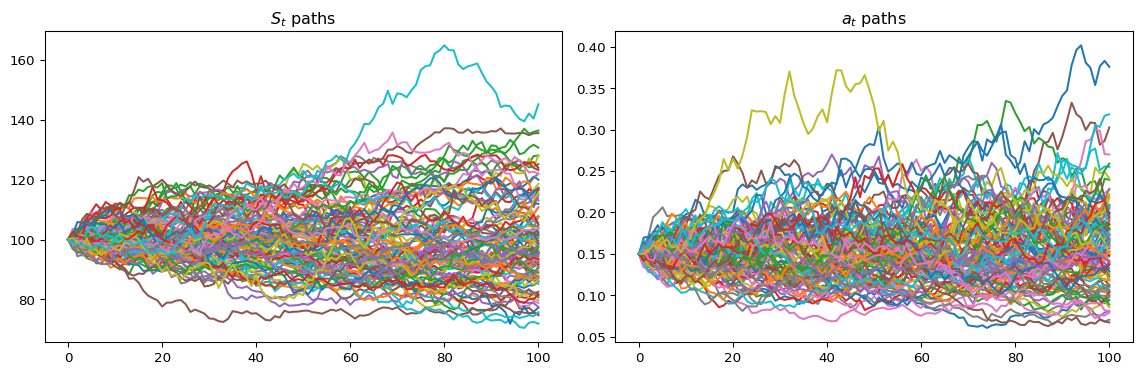

In [5]:
import matplotlib.pyplot as plt

# Show simulation paths
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[1].plot(sigma0 * np.exp(Y_paths[:, :100]))
axes[1].set_title("$a_t$ paths")

axes[0].set_title(f"$S_t$ paths")
axes[0].plot(S_paths[:, :100])

plt.tight_layout()
plt.show()

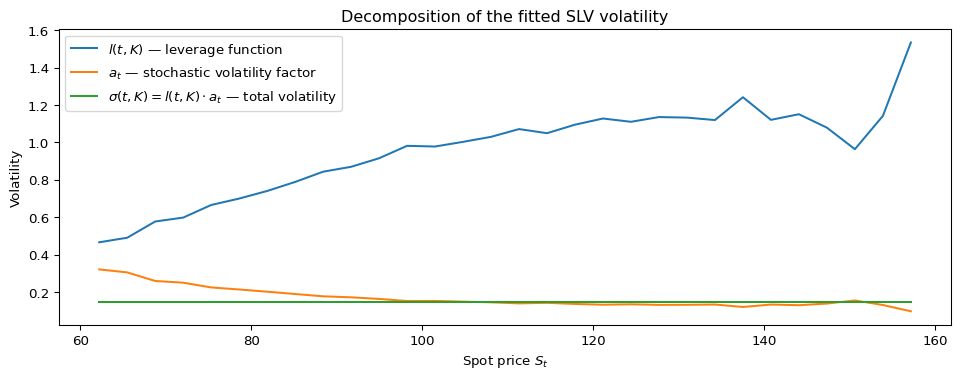

In [6]:
# Decomposition of leverage functions
#=======================

K_grid = K_grids[max(K_grids.keys())]
l_vals = splines[max(splines.keys())](K_grid)
a_vals = Stoch_vol[max(Stoch_vol.keys())]

plt.figure(figsize=(12, 4))
plt.plot(K_grid, l_vals, label=r'$l(t, K)$ — leverage function')
plt.plot(K_grid, a_vals, label=r'$a_t$ — stochastic volatility factor')
plt.plot(K_grid, l_vals * a_vals, label=r'$\sigma(t, K) = l(t,K)\cdot a_t$ — total volatility')
plt.xlabel("Spot price $S_t$")
plt.ylabel("Volatility")
plt.title("Decomposition of the fitted SLV volatility")
plt.legend()
plt.show()

In [7]:
# ── Étape C : Prix des calls et volatilités implicites
print(f"\n{'Strike':>8}  {'Call MC':>10}  {'Call BS':>10}  {'IV hat':>10}  {'Erreur (bp)':>12}")
print("-" * 58)

S_T = S_paths[-1,:] # spot prices at T
for K in strikes:
    # Prix Monte-Carlo
    call_mc = np.mean(np.maximum(S_T - K, 0))

    # Prix Black-Scholes à sigma_mkt
    call_bs = blackscholes_price(K=K,T=T,S=S0,vol=sigma_mkt,callput='call')

    # Volatilité implicite
    try:
        iv = vec_find_vol_rat(price=call_mc, S=S0, K=K, t=T, r=0, flag='c')        
        err_bp = np.abs(iv - sigma_mkt)* 1e4
        print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {iv:>10.4%}  {err_bp:>+12.1f}")
    except Exception:
        print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {'  N/A':>10}  {'  N/A':>12}")

print("-" * 58)
ivs = []
for K in strikes:
    try:
        price = np.mean(np.maximum(S_T - K, 0))
        ivs.append(vec_find_vol_rat(price, S0, K, T, 0, 'c'))
    except Exception:
        ivs.append(np.nan)
ivs = np.array(ivs)
valid = ~np.isnan(ivs)
mae_bp = np.mean(np.abs(ivs[valid] - sigma_mkt)) * 1e4
print(f"Erreur absolue moyenne : {mae_bp:.1f} bp")
print("=" * 60)


  Strike     Call MC     Call BS      IV hat   Erreur (bp)
----------------------------------------------------------
      70     29.9864     30.0364         N/A           N/A
      80     20.3591     20.4036    14.6103%         +39.0
      90     11.9921     12.0217    14.8995%         +10.1
     100      5.9669      5.9785    14.9707%          +2.9
     110      2.4937      2.5002    14.9808%          +1.9
     120      0.8999      0.8913    15.0412%          +4.1
     130      0.2881      0.2766    15.1156%         +11.6
     140      0.0830      0.0765    15.1659%         +16.6
----------------------------------------------------------
Erreur absolue moyenne : 12.3 bp


### Mathematical details of simulation

#### Simulation of the volatility factor

The Ornstein--Uhlenbeck process $Y$ admits the explicit representation

$$
Y_{t_i}
=
e^{-\kappa \Delta t_i}Y_{t_{i-1}}
+
\int_{t_{i-1}}^{t_i}
\gamma e^{-\kappa(t_i-s)}dW_s^{(2)}.
$$

Conditionally on $Y_{t_{i-1}}$, the random variable $Y_{t_i}$ is Gaussian with conditional moments

$$
\mathbb{E}\left[
Y_{t_i}\mid Y_{t_{i-1}}
\right]
=
e^{-\kappa\Delta t_i}Y_{t_{i-1}},
$$

and

$$
\operatorname{Var}\left[
Y_{t_i}\mid Y_{t_{i-1}}
\right]
=
\frac{\gamma^2}{2\kappa}
\left(
1-e^{-2\kappa\Delta t_i}
\right).
$$

Hence, the volatility factor can be simulated exactly on each time interval.

#### Simulation of the spot process

To simulate the spot process, we use a log-Euler discretization scheme. Over the interval $[t_{i-1},t_i]$, the volatility factor and the leverage function are frozen at their left-endpoint values. Thus,

$$
\log S_{t_i}-\log S_{t_{i-1}}
=
-\frac12
\sigma_0^2 e^{2Y_{t_{i-1}}}
l^2(t_{i-1},S_{t_{i-1}})
\Delta t_i
+
\sigma_0 e^{Y_{t_{i-1}}}
l(t_{i-1},S_{t_{i-1}})
\int_{t_{i-1}}^{t_i}dW_t^{(1)}.
$$

Conditionally on $(S_{t_{i-1}},Y_{t_{i-1}})$, the pair $(\log S_{t_i},Y_{t_i})$ is jointly Gaussian.

Its conditional expectation for the log-spot is

$$
\mathbb{E}
\left[
\log S_{t_i}
\mid
S_{t_{i-1}},Y_{t_{i-1}}
\right]
=
\log S_{t_{i-1}}
-
\frac12
\sigma_0^2 e^{2Y_{t_{i-1}}}
l^2(t_{i-1},S_{t_{i-1}})
\Delta t_i.
$$

Its conditional variance is

$$
\operatorname{Var}
\left[
\log S_{t_i}
\mid
S_{t_{i-1}},Y_{t_{i-1}}
\right]
=
\sigma_0^2 e^{2Y_{t_{i-1}}}
l^2(t_{i-1},S_{t_{i-1}})
\Delta t_i.
$$

Finally, the conditional covariance between $Y_{t_i}$ and $\log S_{t_i}$ is

$$
\operatorname{Cov}
\left[
Y_{t_i},\log S_{t_i}
\mid
S_{t_{i-1}},Y_{t_{i-1}}
\right]
=
\sigma_0 e^{Y_{t_{i-1}}}
l(t_{i-1},S_{t_{i-1}})
\frac{\gamma\rho}{\kappa}
\left(
1-e^{-\kappa\Delta t_i}
\right).
$$

Equivalently, the corresponding conditional correlation is

$$
\bar{\rho}
=
\rho
\sqrt{
\frac{
2(1-e^{-\kappa\Delta t_i})
}{
\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})
}
}.
$$

#### Numerical scheme

Using the previous conditional moments, one can jointly simulate $(\log S_{t_i},Y_{t_i})$ by generating two independent standard Gaussian random variables $Z_1$ and $Z_2$.

The simulation scheme is then

$$
\begin{cases}
\log S_{t_i}
=
\log S_{t_{i-1}}
-
\frac12
\sigma_0^2 e^{2Y_{t_{i-1}}}
l^2(t_{i-1},S_{t_{i-1}})
\Delta t_i
+
\sigma_0 e^{Y_{t_{i-1}}}
l(t_{i-1},S_{t_{i-1}})
\sqrt{\Delta t_i}
\left(
\sqrt{1-\bar{\rho}^2}Z_1+\bar{\rho}Z_2
\right),
\\[8pt]
Y_{t_i}
=
e^{-\kappa\Delta t_i}Y_{t_{i-1}}
+
\gamma
\sqrt{
\frac{1-e^{-2\kappa\Delta t_i}}{2\kappa}
}
Z_2.
\end{cases}
$$

This procedure is repeated sequentially over all time intervals $[t_{i-1},t_i]$ in order to generate Monte Carlo trajectories of the SLV model.